In [1]:
import pandas as pd
from glob import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Part 1: For sold dataset

In [2]:
sold_combined = pd.read_csv('../data/generated/combined_sold.csv')

/var/folders/23/ffpfhtdx4wx901rhxgr55x4w0000gn/T/ipykernel_59626/1740595650.py:1: DtypeWarning: Columns (0: BuyerAgentAOR, 1: ListAgentAOR, 2: WaterfrontYN, 3: ListAgentEmail, 4: OriginatingSystemName, 5: OriginatingSystemSubName, 6: BuyerAgencyCompensationType, 7: latfilled, 8: lonfilled) have mixed types. Specify dtype option on import or set low_memory=False.
  sold_combined = pd.read_csv('../data/generated/combined_sold.csv')


## 1. Inspect structure

In [3]:
sold_combined.columns

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN',
       'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey',
       'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName',
       'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
       'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName',
       'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName',
       'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea',
       'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount',
       'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric',
       'ListingId', 'BathroomsTotalInteger', 'City', '

In [65]:
sold_combined.shape

(591733, 84)

In [4]:
sold_combined.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,...,94401,6472.0,NaN,NaN,CRMLS,CRMLS_MLSL,NaN,NaN,NaN,NaN
1,HighDesert,HighDesert,NaN,NaN,NaN,NaN,NaN,0.0,535486633,eabrown@lee-associates.com,...,92394,NaN,52320.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN
2,OrangeCounty,OrangeCounty,NaN,True,NaN,NaN,NaN,75000.0,529986282,Joe@9WINWIN.com,...,93240,NaN,217364.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN
3,InlandValleys,InlandValleys,NaN,True,NaN,NaN,NaN,199000.0,529618166,carolthefinder@yahoo.com,...,92308,NaN,217800.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN
4,SouthwestRiversideCounty,SouthwestRiversideCounty,NaN,True,NaN,NaN,NaN,19500.0,522614340,jtavisola@tavisola.com,...,93544,0.0,108883.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN


In [5]:
sold_combined.info()

<class 'pandas.DataFrame'>
RangeIndex: 591733 entries, 0 to 591732
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 520175 non-null  str    
 1   ListAgentAOR                  523685 non-null  str    
 2   Flooring                      347801 non-null  str    
 3   ViewYN                        532453 non-null  object 
 4   WaterfrontYN                  323 non-null     object 
 5   BasementYN                    9760 non-null    object 
 6   PoolPrivateYN                 517524 non-null  object 
 7   OriginalListPrice             590013 non-null  float64
 8   ListingKey                    591733 non-null  int64  
 9   ListAgentEmail                547714 non-null  str    
 10  CloseDate                     591733 non-null  str    
 11  ClosePrice                    591726 non-null  float64
 12  ListAgentFirstName            588300 non-null  str    


Sold rows before Residential filter: 591733

## 2. Property type validation

**Q1: What property types exist?**

In [67]:
sold_combined['PropertyType'].unique()

<ArrowStringArray>
[        'Residential',     'CommercialLease',                'Land',
    'ResidentialLease',  'ManufacturedInPark',   'ResidentialIncome',
      'CommercialSale', 'BusinessOpportunity']
Length: 8, dtype: str

In [7]:
sold_combined['PropertyType'].value_counts(dropna=False)

PropertyType
Residential            397603
ResidentialLease       135617
Land                    19345
ManufacturedInPark      16082
ResidentialIncome       15865
CommercialSale           3714
CommercialLease          3104
BusinessOpportunity       403
Name: count, dtype: int64

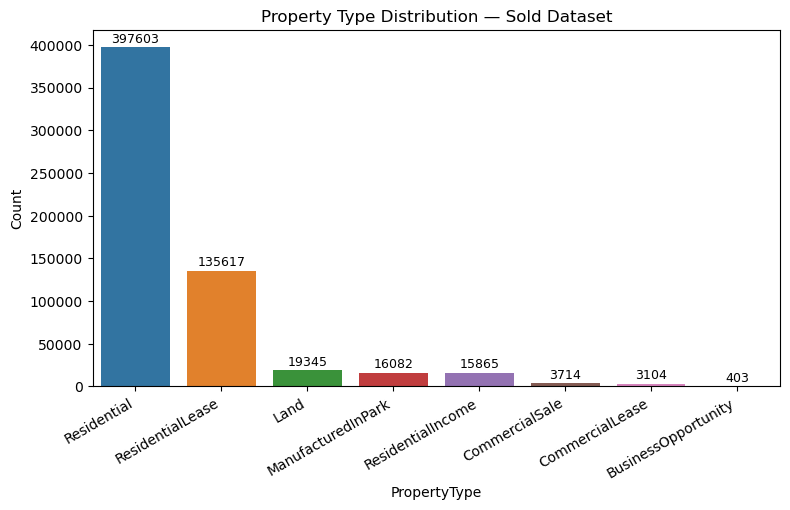

In [8]:
sold_property = sold_combined.copy()

sold_property_count = sold_property['PropertyType'].value_counts().reset_index()

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=sold_property_count,
    x='PropertyType',
    y='count',
    hue='PropertyType'
)

for bar in ax.patches:
    height = bar.get_height()
    x = bar.get_x() + bar.get_width() / 2
    plt.text(
        x,
        height + 2000,   
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.title('Property Type Distribution — Sold Dataset')
plt.show()

The property type distribution shows that the raw sold dataset is not limited to standard residential transactions. Although Residential is the primary category, the dataset also includes lease, land, manufactured housing, income, and commercial-related records. Therefore, filtering to Residential only is a necessary validation step to ensure the analysis population is consistent with the intended residential market focus.

**Q2: What is the Residential vs. other property type share?**

In [9]:
sold_property_count

,PropertyType,count
0,Residential,397603
1,ResidentialLease,135617
2,Land,19345
3,ManufacturedInPark,16082
4,ResidentialIncome,15865
5,CommercialSale,3714
6,CommercialLease,3104
7,BusinessOpportunity,403


In [73]:
residential_count = sold_property_count.loc[
    sold_property_count['PropertyType'] == 'Residential', 'count'
].iloc[0]
total_count = len(sold_combined)
other_count = total_count - residential_count

residential_pct = residential_count / total_count * 100
other_pct = other_count / total_count * 100

print(f"Residential share on Sold Dataset: {residential_pct:.2f}%")
print(f"Other share on Sold Dataset: {other_pct:.2f}%")

Residential share on Sold Dataset: 67.19%
Other share on Sold Dataset: 32.81%


Residential properties make up 67.19% of the combined sold dataset, compared with 32.81% for all other property types. 

## 3. Structure inspection on filtered residential data

In [11]:
#use filtered dataset
sold_combined_residential = pd.read_csv('../data/generated/combined_sold_residential.csv')

/var/folders/23/ffpfhtdx4wx901rhxgr55x4w0000gn/T/ipykernel_59626/2233278480.py:2: DtypeWarning: Columns (0: BuyerAgentAOR, 1: ListAgentAOR, 2: ListAgentEmail, 3: FireplaceYN, 4: OriginatingSystemName, 5: OriginatingSystemSubName, 6: BuyerAgencyCompensationType, 7: latfilled, 8: lonfilled) have mixed types. Specify dtype option on import or set low_memory=False.
  sold_combined_residential = pd.read_csv('../data/generated/combined_sold_residential.csv')


In [12]:
sold_combined_residential.info()

<class 'pandas.DataFrame'>
RangeIndex: 397603 entries, 0 to 397602
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 348512 non-null  str    
 1   ListAgentAOR                  351417 non-null  str    
 2   Flooring                      255013 non-null  str    
 3   ViewYN                        363734 non-null  object 
 4   WaterfrontYN                  248 non-null     object 
 5   BasementYN                    7777 non-null    object 
 6   PoolPrivateYN                 363168 non-null  object 
 7   OriginalListPrice             396882 non-null  float64
 8   ListingKey                    397603 non-null  int64  
 9   ListAgentEmail                368591 non-null  str    
 10  CloseDate                     397603 non-null  str    
 11  ClosePrice                    397601 non-null  float64
 12  ListAgentFirstName            394604 non-null  str    


Sold rows after Residential filter: 397603

In [13]:
sold_combined_residential.shape

(397603, 84)

In [14]:
sold_combined_residential.columns

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN',
       'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey',
       'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName',
       'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
       'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName',
       'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName',
       'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea',
       'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount',
       'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric',
       'ListingId', 'BathroomsTotalInteger', 'City', '

In [15]:
sold_combined_residential.info()

<class 'pandas.DataFrame'>
RangeIndex: 397603 entries, 0 to 397602
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 348512 non-null  str    
 1   ListAgentAOR                  351417 non-null  str    
 2   Flooring                      255013 non-null  str    
 3   ViewYN                        363734 non-null  object 
 4   WaterfrontYN                  248 non-null     object 
 5   BasementYN                    7777 non-null    object 
 6   PoolPrivateYN                 363168 non-null  object 
 7   OriginalListPrice             396882 non-null  float64
 8   ListingKey                    397603 non-null  int64  
 9   ListAgentEmail                368591 non-null  str    
 10  CloseDate                     397603 non-null  str    
 11  ClosePrice                    397601 non-null  float64
 12  ListAgentFirstName            394604 non-null  str    


In [16]:
sold_combined_residential.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,...,94401,6472.0,NaN,NaN,CRMLS,CRMLS_MLSL,NaN,NaN,NaN,NaN
1,SanDiego,SanDiego,NaN,False,NaN,NaN,False,759900.0,522107581,mdarwich12@gmail.com,...,91950,NaN,NaN,NaN,CRMLS,CRMLS_SAND,NaN,NaN,NaN,NaN
2,SanDiego,SanDiego,NaN,False,NaN,NaN,False,739900.0,510919001,mdarwich12@gmail.com,...,91950,NaN,NaN,NaN,CRMLS,CRMLS_SAND,NaN,NaN,NaN,NaN
3,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,NaN,1079166779,davidmartz@compass.com,...,92262,NaN,13504.0,NaN,CRMLS,CRMLS_MLSL,NaN,NaN,NaN,NaN
4,Southland,Southland,NaN,False,NaN,NaN,False,1890500.0,1075037759,karen.klein@theagencyre.com,...,91356,0.0,17873.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN


The filtered residential sold dataset retains 397,603 observations across 84 columns, showing that a substantial residential analysis sample remains after applying the property type filter. Core market-analysis variables such as ClosePrice, ListPrice, OriginalListPrice, LivingArea, DaysOnMarket, CountyOrParish, City, and the major transaction date fields are all present, so the dataset contains the key information needed for subsequent EDA. Most major pricing and housing characteristic fields already have appropriate numeric data types, but several date variables are still stored as strings and will need to be converted to datetime in later cleaning.

## 4. Missing value analysis

In [17]:
sold_combined_residential.isnull().sum()

BuyerAgentAOR                   49091
ListAgentAOR                    46186
Flooring                       142590
ViewYN                          33869
WaterfrontYN                   397355
                                ...  
OriginatingSystemSubName       358351
BuyerAgencyCompensationType    351467
BuyerAgencyCompensation        351478
latfilled                      333719
lonfilled                      333719
Length: 84, dtype: int64

In [18]:
missing_report = pd.DataFrame({
    'column': sold_combined_residential.columns,
    'null_count': sold_combined_residential.isnull().sum().values,
    'null_pct': sold_combined_residential.isnull().sum().values / len(sold_combined_residential) * 100
})

missing_report['gt_90pct_missing'] = missing_report['null_pct'] > 90
missing_report = missing_report.sort_values('null_pct', ascending=False)
missing_report

,column,null_count,null_pct,gt_90pct_missing
62,CoveredSpaces,397603,100.0,True
77,MiddleOrJuniorSchoolDistrict,397603,100.0,True
32,AboveGradeFinishedArea,397603,100.0,True
30,FireplacesTotal,397603,100.0,True
51,TaxYear,397603,100.0,True
...,...,...,...,...
20,DaysOnMarket,0,0.0,False
21,ListOfficeName,0,0.0,False
48,ListingId,0,0.0,False
33,ListingKeyNumeric,0,0.0,False


In [19]:
missing_report[missing_report['gt_90pct_missing'] == True][['column','null_pct']]

,column,null_pct
62,CoveredSpaces,100.000000
77,MiddleOrJuniorSchoolDistrict,100.000000
32,AboveGradeFinishedArea,100.000000
30,FireplacesTotal,100.000000
51,TaxYear,100.000000
55,ElementarySchoolDistrict,100.000000
60,BusinessType,100.000000
35,TaxAnnualAmount,100.000000
4,WaterfrontYN,99.937626
59,BelowGradeFinishedArea,99.424049


For the flagged columns(missing percentage greater than 90%), there are no clear must-keep core variables. Thus, Those high-missing, low-value columns should be dropped.

In [20]:
sold_cleaned = sold_combined_residential.drop(columns=missing_report[missing_report['gt_90pct_missing'] == True]['column'].tolist()).copy()

In [21]:
sold_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 397603 entries, 0 to 397602
Data columns (total 67 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   BuyerAgentAOR                348512 non-null  str    
 1   ListAgentAOR                 351417 non-null  str    
 2   Flooring                     255013 non-null  str    
 3   ViewYN                       363734 non-null  object 
 4   PoolPrivateYN                363168 non-null  object 
 5   OriginalListPrice            396882 non-null  float64
 6   ListingKey                   397603 non-null  int64  
 7   ListAgentEmail               368591 non-null  str    
 8   CloseDate                    397603 non-null  str    
 9   ClosePrice                   397601 non-null  float64
 10  ListAgentFirstName           394604 non-null  str    
 11  ListAgentLastName            397563 non-null  str    
 12  Latitude                     381781 non-null  float64
 13  Longitude 

In [110]:
sold_cleaned.to_csv('../data/generated/sold_cleaned.csv', index=False)

## 5. Numeric distribution review

In [22]:
# identify numeric columns
numeric_keys = [
    'ClosePrice',
    'ListPrice',
    'OriginalListPrice',
    'LivingArea',
    'LotSizeAcres',
    'BedroomsTotal',
    'BathroomsTotalInteger',
    'DaysOnMarket',
    'YearBuilt'
]

In [82]:
#summary statistics for key numeric columns
sold_cleaned[numeric_keys].describe()

,ClosePrice,ListPrice,OriginalListPrice,LivingArea,LotSizeAcres,BedroomsTotal,BathroomsTotalInteger,DaysOnMarket,YearBuilt
count,3.976010e+05,3.976030e+05,3.968820e+05,3.973740e+05,3.662390e+05,397592.000000,397534.000000,397603.000000,397247.000000
mean,1.185616e+06,1.138630e+06,1.224737e+06,1.904351e+03,6.855894e+01,3.200200,2.533185,37.336788,1978.567921
std,5.922380e+06,1.353707e+06,6.779804e+06,2.701781e+04,1.632724e+04,1.067419,1.135979,53.539245,26.272785
min,0.000000e+00,5.250000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,-288.000000,1776.000000
25%,5.750000e+05,5.750000e+05,5.850000e+05,1.247000e+03,1.200000e-01,3.000000,2.000000,8.000000,1960.000000
50%,8.200000e+05,8.150000e+05,8.250000e+05,1.641000e+03,1.663000e-01,3.000000,2.000000,19.000000,1979.000000
75%,1.300000e+06,1.295000e+06,1.299000e+06,2.217000e+03,2.724000e-01,4.000000,3.000000,48.000000,1999.000000
max,9.895000e+08,1.375000e+08,1.390000e+09,1.702132e+07,7.810698e+06,45.000000,175.000000,12430.000000,2026.000000


The numeric distribution review indicates that the residential sold dataset contains both invalid values and extreme right-tail outliers. *DaysOnMarket* includes **negative observations**, which are not logically valid. And several core variables such as *ClosePrice, OriginalListPrice, LivingArea, and LotSizeAcres* contain **zero values** that may represent invalid or placeholder entries. In addition, the large gaps between medians and maximum values — for example in *ClosePrice, LivingArea, LotSizeAcres, and BathroomsTotalInteger* — show that the data is **highly skewed** and includes unusually large observations that will need to be flagged or addressed in later cleaning steps.

In [99]:
#percentile summary for key numeric columns
percentile_summary_sold = (sold_cleaned[numeric_keys].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T)[
    ['min', '1%', '5%', '25%', '50%', '75%', '95%', '99%', 'max']
]

percentile_summary_sold

,min,1%,5%,25%,50%,75%,95%,99%,max
ClosePrice,0.0,203000.0,340000.00,575000.00,820000.0000,1.300000e+06,2850000.00,5.550000e+06,9.895000e+08
ListPrice,525.0,214990.1,346500.00,575000.00,815000.0000,1.295000e+06,2850000.00,5.695000e+06,1.375000e+08
OriginalListPrice,0.0,210405.0,349900.00,585000.00,825000.0000,1.299000e+06,2899000.00,5.995000e+06,1.390000e+09
LivingArea,0.0,604.0,839.00,1247.00,1641.0000,2.217000e+03,3558.00,5.280000e+03,1.702132e+07
LotSizeAcres,0.0,0.0,0.03,0.12,0.1663,2.724000e-01,2.81,1.079935e+01,7.810698e+06
BedroomsTotal,0.0,1.0,2.00,3.00,3.0000,4.000000e+00,5.00,6.000000e+00,4.500000e+01
BathroomsTotalInteger,0.0,1.0,1.00,2.00,2.0000,3.000000e+00,4.00,6.000000e+00,1.750000e+02
DaysOnMarket,-288.0,0.0,1.00,8.00,19.0000,4.800000e+01,131.00,2.290000e+02,1.243000e+04
YearBuilt,1776.0,1912.0,1930.00,1960.00,1979.0000,1.999000e+03,2022.00,2.025000e+03,2.026000e+03


### **5.1 Histogram for each key numeric variables**

Close Price is behaving exactly the way a highly right-skewed variable with extreme outliers behaves.

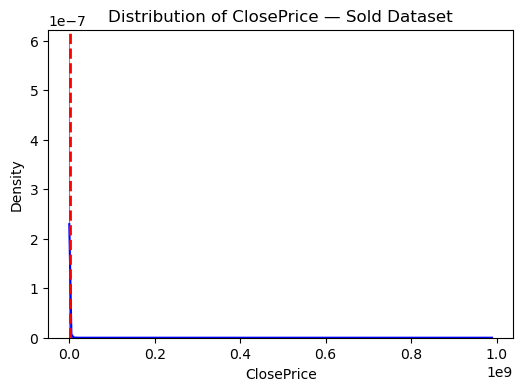

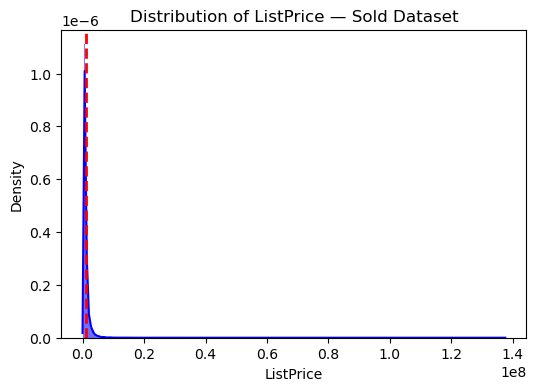

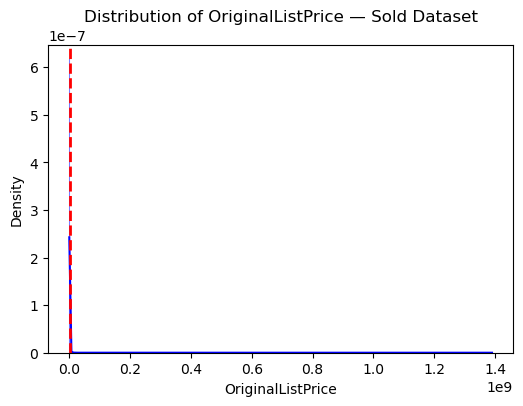

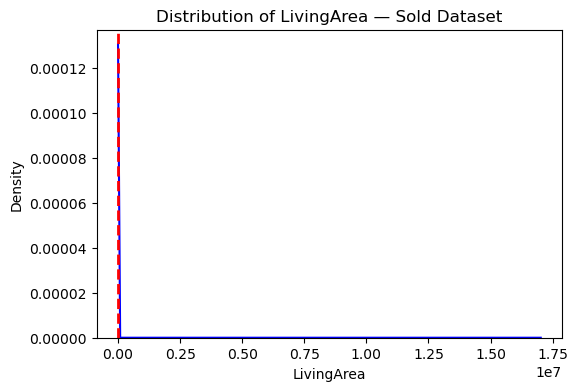

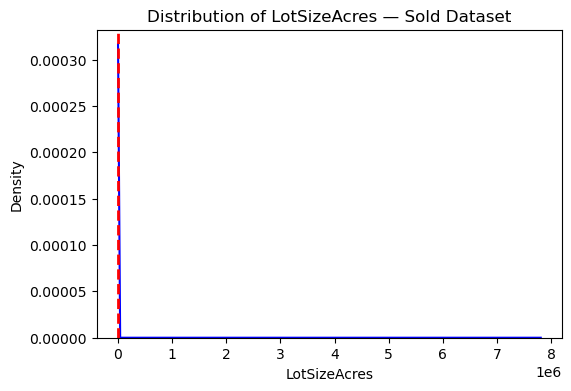

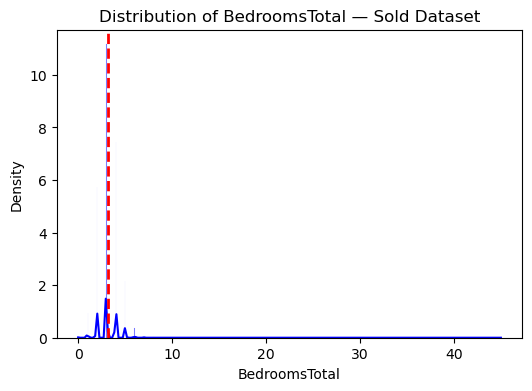

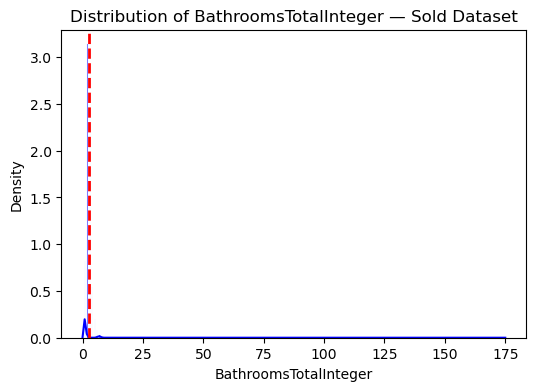

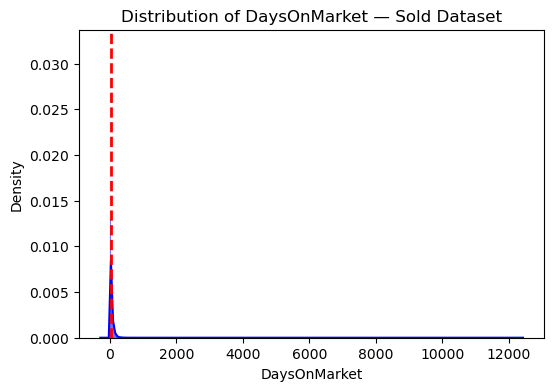

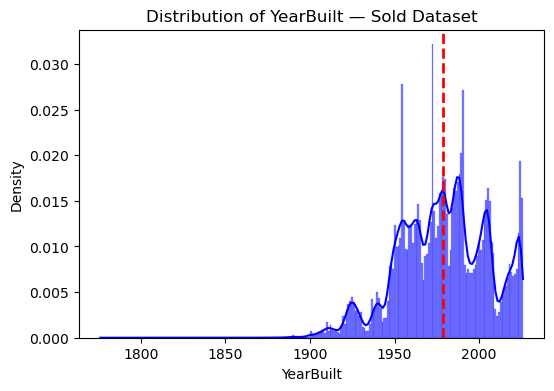

In [98]:
for col in numeric_keys:
    plt.figure(figsize=(6,4))
    sns.histplot(data = sold_cleaned,
             x = col, 
             edgecolor = 'blue',
             color = 'blue',
             stat='density',
             kde=True
             )
    mean_value = sold_cleaned[col].mean()
    plt.axvline(x = mean_value,
                         color = 'red',
                         linestyle = '--',
                         linewidth = 2) #vertical line
    plt.title(f'Distribution of {col} — Sold Dataset')

The histogram review shows that several key residential variables — including *ClosePrice, ListPrice, OriginalListPrice, LivingArea, LotSizeAcres, and DaysOnMarket* — are **highly right-skewed** and contain **extreme upper-tail** observations. In contrast, *BedroomsTotal and BathroomsTotalInteger* are concentrated around typical residential values but still contain unusually large observations, while *YearBuilt* has a more interpretable historical distribution centered in the modern period. Overall, the plots confirm that the dataset contains both implausible values and substantial outliers, indicating that later cleaning steps should include invalid-value checks and outlier treatment before final market analysis.

### **5.2 Boxplot**

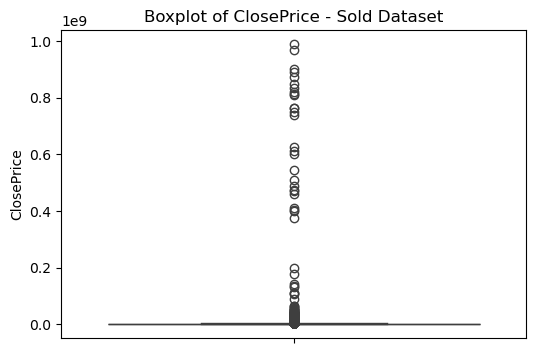

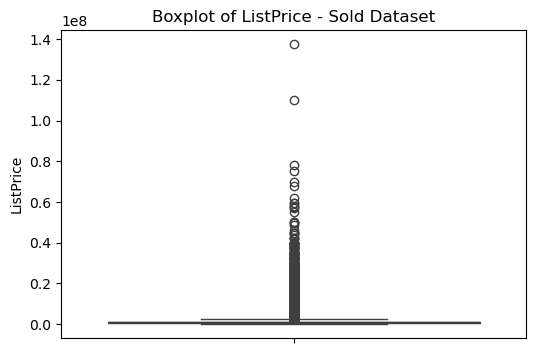

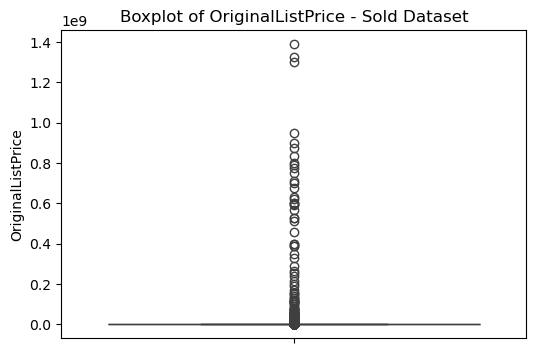

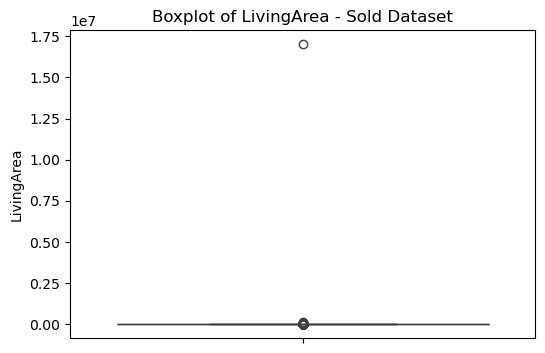

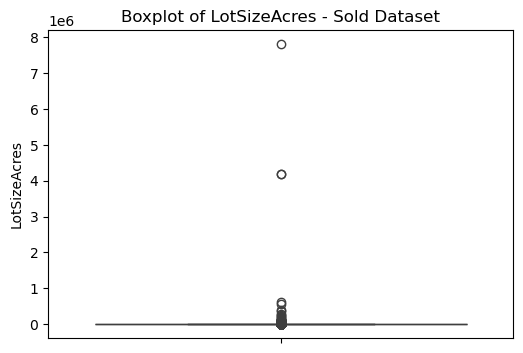

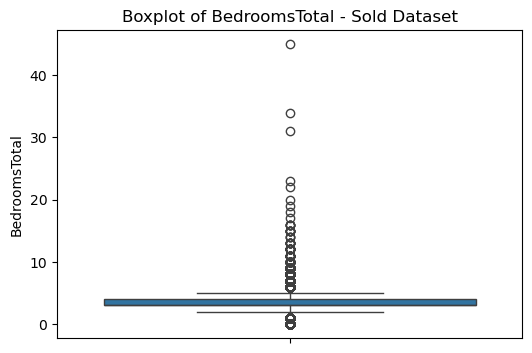

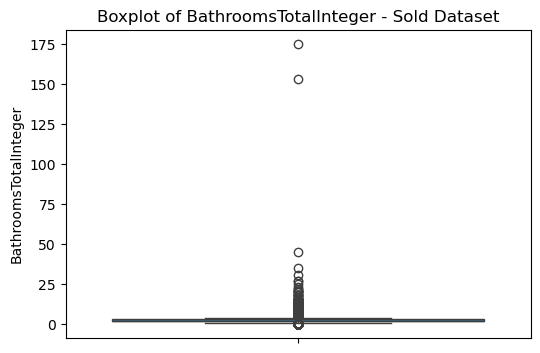

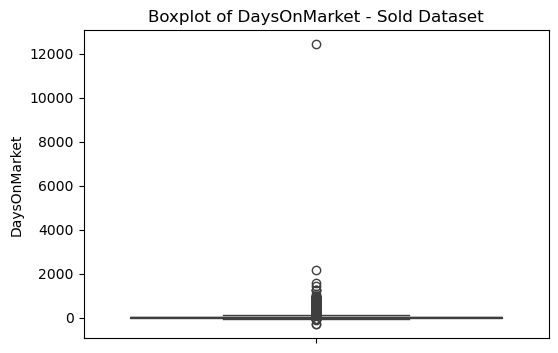

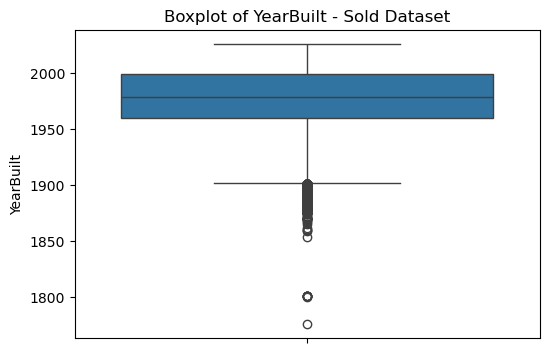

In [97]:
for col in numeric_keys:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=sold_cleaned[col])
    plt.title(f'Boxplot of {col} - Sold Dataset')

The boxplots confirm the conclusions from the histograms by showing that several key numeric variables are highly right-skewed and contain substantial outliers.

## 6. Outlier and strange values

### 6.1. Outlier values applied IQR method

In [96]:
for col in numeric_keys:
    #Identifying outliers using boxplot method for each key numeric column
    Q1 = sold_cleaned[col].quantile(0.25)
    Q3 = sold_cleaned[col].quantile(0.75)


    # Calculate the Interquartile Range (IQR)
    IQR = Q3 - Q1

    # Calculate the upper bound for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5*IQR

    print(f'Outlier bounds for {col} - Sold Dataset: [{lower_bound:.2f}, {upper_bound:.2f}]')

    outliers = sold_cleaned[(sold_cleaned[col] > upper_bound) | (sold_cleaned[col] < lower_bound)]
    print(f'Percentage of {col} outliers - Sold Dataset:', round(len(outliers) / len(sold_cleaned) * 100,2),'%\n')


Outlier bounds for ClosePrice - Sold Dataset: [-512500.00, 2387500.00]
Percentage of ClosePrice outliers - Sold Dataset: 7.4 %

Outlier bounds for ListPrice - Sold Dataset: [-505000.00, 2375000.00]
Percentage of ListPrice outliers - Sold Dataset: 7.44 %

Outlier bounds for OriginalListPrice - Sold Dataset: [-486000.00, 2370000.00]
Percentage of OriginalListPrice outliers - Sold Dataset: 7.76 %

Outlier bounds for LivingArea - Sold Dataset: [-208.00, 3672.00]
Percentage of LivingArea outliers - Sold Dataset: 4.41 %

Outlier bounds for LotSizeAcres - Sold Dataset: [-0.11, 0.50]
Percentage of LotSizeAcres outliers - Sold Dataset: 14.33 %

Outlier bounds for BedroomsTotal - Sold Dataset: [1.50, 5.50]
Percentage of BedroomsTotal outliers - Sold Dataset: 5.51 %

Outlier bounds for BathroomsTotalInteger - Sold Dataset: [0.50, 4.50]
Percentage of BathroomsTotalInteger outliers - Sold Dataset: 4.59 %

Outlier bounds for DaysOnMarket - Sold Dataset: [-52.00, 108.00]
Percentage of DaysOnMarket ou

### 6.2. Strange values
-  Invalid : 
    * DaysOnMarket < 0
	* ClosePrice = 0
	* OriginalListPrice = 0
	* LivingArea = 0
	* LotSizeAcres = 0
	* BedroomsTotal = 0
	* BathroomsTotalInteger = 0
- Very large:
	* BedroomsTotal = 45
	* BathroomsTotalInteger = 175
	* LivingArea = 17,021,320
	* LotSizeAcres = 7,810,698

- Unusual but may be possible:
	* YearBuilt = 1776


## 7. EDA question

1.  What are the median and average close prices?

In [57]:
median_close_price = sold_cleaned['ClosePrice'].median()
mean_close_price = sold_cleaned['ClosePrice'].mean()

print("Median ClosePrice:", median_close_price)
print("Average ClosePrice:", mean_close_price)

Median ClosePrice: 820000.0
Average ClosePrice: 1185616.3601253768


2. What does the Days on Market distribution look like?

In [48]:
sold_cleaned['DaysOnMarket'].describe()

count    397603.000000
mean         37.336788
std          53.539245
min        -288.000000
25%           8.000000
50%          19.000000
75%          48.000000
max       12430.000000
Name: DaysOnMarket, dtype: float64

Histagram:

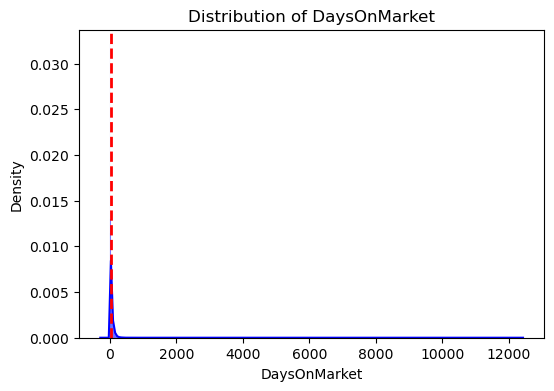

*Days on Market* is strongly right-skewed, with most observations clustered at lower values and a long upper tail of extreme observations. It also includes negative values, which are invalid, and the large gap between the median and maximum indicates substantial upper-tail outliers.

3. What percentage of homes sold above vs. below list price?

In [51]:
above_list_price = sold_cleaned[sold_cleaned['ClosePrice'] > sold_cleaned['ListPrice']]
below_list_price = sold_cleaned[sold_cleaned['ClosePrice'] < sold_cleaned['ListPrice']]
equal_list_price = sold_cleaned[sold_cleaned['ClosePrice'] == sold_cleaned['ListPrice']]

# since some rows may have missing values in either ClosePrice or ListPrice, we should only consider rows where both are present for percentage calculations

total_valid = len(sold_cleaned[['ClosePrice', 'ListPrice']].dropna())

above_pct = len(above_list_price) / total_valid * 100
below_pct = len(below_list_price) / total_valid * 100
at_pct = len(equal_list_price) / total_valid * 100

print("Above list percentage:", f"{above_pct:.2f}%")
print("Below list percentage:", f"{below_pct:.2f}%")

Above list percentage: 40.11%
Below list percentage: 42.54%


4. Are there any apparent date consistency issues (e.g., close date before listing date)?

In [107]:
#convert to datetime
sold_cleaned['CloseDate'] = pd.to_datetime(sold_cleaned['CloseDate'], errors='coerce')
sold_cleaned['ListingContractDate'] = pd.to_datetime(sold_cleaned['ListingContractDate'], errors='coerce')
sold_cleaned['PurchaseContractDate'] = pd.to_datetime(sold_cleaned['PurchaseContractDate'], errors='coerce')


close_before_listing = (sold_cleaned['CloseDate'] < sold_cleaned['ListingContractDate']).sum()
close_before_purchase = (sold_cleaned['CloseDate'] < sold_cleaned['PurchaseContractDate']).sum()
purchase_before_listing = (sold_cleaned['PurchaseContractDate'] < sold_cleaned['ListingContractDate']).sum()

print("Close date before listing date - sold dataset:", close_before_listing)
print("Close date before purchase contract date - sold dataset:", close_before_purchase)
print("Purchase contract date before listing date - sold dataset:", purchase_before_listing)

Close date before listing date - sold dataset: 58
Close date before purchase contract date - sold dataset: 240
Purchase contract date before listing date - sold dataset: 261


5. Which counties have the highest median prices?

In [56]:
county_median_prices = (
    sold_cleaned
    .groupby('CountyOrParish')['ClosePrice']
    .median()
    .sort_values(ascending=False)
)

county_median_prices.head(10)

CountyOrParish
Del Norte        2485000.0
Other County     2462500.0
San Mateo        1700000.0
Santa Clara      1600000.0
Santa Cruz       1200000.0
San Francisco    1180000.0
Orange           1175000.0
Marin            1170000.0
Alameda          1135000.0
Alpine           1100000.0
Name: ClosePrice, dtype: float64

The counties with the highest median close prices are Del Norte. 

# Part 2: For listing dataset

In [61]:
listing_combined = pd.read_csv('../data/generated/combined_listing.csv')

/var/folders/23/ffpfhtdx4wx901rhxgr55x4w0000gn/T/ipykernel_59626/265415849.py:1: DtypeWarning: Columns (0: ListAgentEmail, 1: BuyerAgencyCompensationType) have mixed types. Specify dtype option on import or set low_memory=False.
  listing_combined = pd.read_csv('../data/generated/combined_listing.csv')


In [62]:
listing_combined.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1
0,90000.0,1075010398,miriamlara03@gmail.com,NaN,NaN,Miriam,Lara,34.097939,-117.909653,1045 N Azusa 61,...,NaN,NaN,2.0,Covina Valley Unified,91722,NaN,0.0,NaN,NaN,1045 N Azusa 61
1,1500000.0,1074974457,janelle@judsonre.com,NaN,NaN,Janelle,Judson,33.121241,-117.081614,NaN,...,NaN,NaN,NaN,NaN,92025,NaN,0.0,NaN,NaN,NaN
2,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,NaN,False,NaN,NaN,90067,NaN,2105.0,177861.0,NaN,2220 Avenue Of The Stars 2704
3,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,0.0,False,3.0,Capistrano Unified,92677,NaN,254.0,5300.0,NaN,16 Palisades
4,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,NaN,NaN,2.0,NaN,91108,NaN,NaN,9404.0,NaN,1615 Waverly Road


## 1. Structure Inspection

In [64]:
listing_combined.shape

(852963, 84)

In [63]:
listing_combined.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'PropertyType.1', 'MlsStatus',
       'ElementarySchool', 'ListAgentFirstName.1', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'DaysOnMarket.1',
       'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'LivingArea.1',
       'ListingId', 'BathroomsTotalInteger', 'Cit

In [66]:
listing_combined.info()

<class 'pandas.DataFrame'>
RangeIndex: 852963 entries, 0 to 852962
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   OriginalListPrice             849641 non-null  float64
 1   ListingKey                    852963 non-null  int64  
 2   ListAgentEmail                780379 non-null  str    
 3   CloseDate                     261640 non-null  str    
 4   ClosePrice                    239043 non-null  float64
 5   ListAgentFirstName            847972 non-null  str    
 6   ListAgentLastName             852888 non-null  str    
 7   Latitude                      741053 non-null  float64
 8   Longitude                     741756 non-null  float64
 9   UnparsedAddress               850832 non-null  str    
 10  PropertyType                  852963 non-null  str    
 11  LivingArea                    746485 non-null  float64
 12  ListPrice                     850826 non-null  float64


Listing rows before Residential filter: 852963

## 2.Property Type Validation

**Q1: What property types exist?**

In [68]:
listing_combined['PropertyType'].unique()

<ArrowStringArray>
[ 'ManufacturedInPark',      'CommercialSale',         'Residential',
    'ResidentialLease',                'Land',   'ResidentialIncome',
     'CommercialLease', 'BusinessOpportunity']
Length: 8, dtype: str

In [69]:
listing_combined['PropertyType'].value_counts(dropna=False)

PropertyType
Residential            540183
ResidentialLease       178041
Land                    56372
ResidentialIncome       31650
ManufacturedInPark      24531
CommercialSale          11715
CommercialLease          7736
BusinessOpportunity      2735
Name: count, dtype: int64

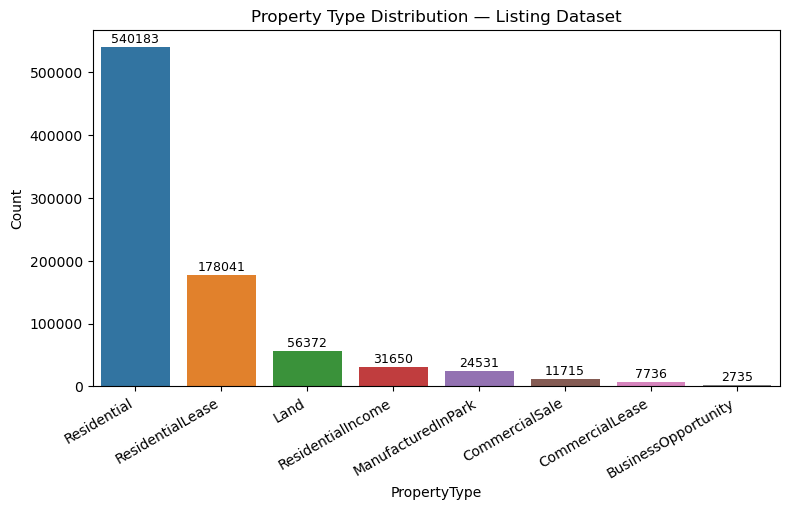

In [70]:
listing_property = listing_combined.copy()

listing_property_count = listing_property['PropertyType'].value_counts().reset_index()

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=listing_property_count,
    x='PropertyType',
    y='count',
    hue='PropertyType'
)

for bar in ax.patches:
    height = bar.get_height()
    x = bar.get_x() + bar.get_width() / 2
    plt.text(
        x,
        height + 2000,   
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.title('Property Type Distribution — Listing Dataset')
plt.show()

The listing dataset includes several property types, but Residential is by far the dominant category with 540,183 records, substantially exceeding all other groups. ResidentialLease is the second-largest category, while the remaining property types make up much smaller portions of the data. This supports applying a only Residential filter so that subsequent analysis focuses only on standard residential listings.

**Q2: What is the Residential vs. other property type share?**

In [71]:
listing_property_count

,PropertyType,count
0,Residential,540183
1,ResidentialLease,178041
2,Land,56372
3,ResidentialIncome,31650
4,ManufacturedInPark,24531
5,CommercialSale,11715
6,CommercialLease,7736
7,BusinessOpportunity,2735


In [72]:
residential_count = listing_property_count.loc[
    listing_property_count['PropertyType'] == 'Residential', 'count'
].iloc[0]
total_count = len(listing_combined)
other_count = total_count - residential_count

residential_pct = residential_count / total_count * 100
other_pct = other_count / total_count * 100

print(f"Residential share on Listing Dataset: {residential_pct:.2f}%")
print(f"Other share on Listing Dataset: {other_pct:.2f}%")

Residential share on Listing Dataset: 63.33%
Other share on Listing Dataset: 36.67%


Residential properties make up 63.33% of the combined listing dataset, compared with 36.67% for all other property types. 

## 3. Structure inspection on filtered residential data

In [74]:
#use filtered dataset
listing_combined_residential = pd.read_csv('../data/generated/combined_listing_residential.csv')

/var/folders/23/ffpfhtdx4wx901rhxgr55x4w0000gn/T/ipykernel_59626/3697888386.py:2: DtypeWarning: Columns (0: ListAgentEmail, 1: BuyerAgencyCompensationType) have mixed types. Specify dtype option on import or set low_memory=False.
  listing_combined_residential = pd.read_csv('../data/generated/combined_listing_residential.csv')


In [75]:
listing_combined_residential.info()

<class 'pandas.DataFrame'>
RangeIndex: 540183 entries, 0 to 540182
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   OriginalListPrice             539409 non-null  float64
 1   ListingKey                    540183 non-null  int64  
 2   ListAgentEmail                493182 non-null  str    
 3   CloseDate                     165822 non-null  str    
 4   ClosePrice                    145580 non-null  float64
 5   ListAgentFirstName            535958 non-null  str    
 6   ListAgentLastName             540144 non-null  str    
 7   Latitude                      460038 non-null  float64
 8   Longitude                     460038 non-null  float64
 9   UnparsedAddress               539513 non-null  str    
 10  PropertyType                  540183 non-null  str    
 11  LivingArea                    539627 non-null  float64
 12  ListPrice                     540183 non-null  float64


Listing rows after Residential filter: 540183

In [76]:
listing_combined_residential.shape

(540183, 84)

In [81]:
listing_combined_residential.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1
0,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,NaN,False,NaN,NaN,90067,NaN,2105.00,177861.0,NaN,2220 Avenue Of The Stars 2704
1,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,0.0,False,3.0,Capistrano Unified,92677,NaN,254.00,5300.0,NaN,16 Palisades
2,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,NaN,NaN,2.0,NaN,91108,NaN,NaN,9404.0,NaN,1615 Waverly Road
3,3090000.0,1074917818,QIANYU0607@GMAIL.COM,NaN,NaN,QIANYU,GUAN,33.984057,-117.802819,2250 Indian Creek Road,...,1.0,False,4.0,Walnut Valley Unified,91765,NaN,295.95,58232.0,NaN,2250 Indian Creek Road
4,12725000.0,1074143166,jeff.williams@pacificsir.com,NaN,NaN,Jeff,Williams,33.607583,-117.887743,317 E. Bayfront,...,3.0,False,2.0,Newport Mesa Unified,92662,NaN,0.00,2250.0,NaN,317 E. Bayfront


## 4. Missing value Analysis

In [83]:
listing_combined_residential.isnull().sum()

OriginalListPrice                  774
ListingKey                           0
ListAgentEmail                   47001
CloseDate                       374361
ClosePrice                      394603
                                 ...  
BuyerOfficeName.1               383233
AssociationFee                  129662
LotSizeSquareFeet                43854
MiddleOrJuniorSchoolDistrict    540183
UnparsedAddress.1                  670
Length: 84, dtype: int64

In [84]:
missing_report_listing = pd.DataFrame({
    'column': listing_combined_residential.columns,
    'null_count': listing_combined_residential.isnull().sum().values,
    'null_pct': listing_combined_residential.isnull().sum().values / len(listing_combined_residential) * 100
})

missing_report_listing['gt_90pct_missing'] = missing_report_listing['null_pct'] > 90
missing_report_listing = missing_report_listing.sort_values('null_pct', ascending=False)
missing_report_listing

,column,null_count,null_pct,gt_90pct_missing
28,TaxAnnualAmount,540183,100.0,True
23,FireplacesTotal,540183,100.0,True
55,ElementarySchoolDistrict,540183,100.0,True
50,TaxYear,540183,100.0,True
60,BusinessType,540183,100.0,True
...,...,...,...,...
31,MlsStatus,0,0.0,False
1,ListingKey,0,0.0,False
46,ListingId,0,0.0,False
62,ListPrice.1,0,0.0,False


In [85]:
missing_report_listing[missing_report_listing['gt_90pct_missing'] == True][['column','null_pct']]

,column,null_pct
28,TaxAnnualAmount,100.000000
23,FireplacesTotal,100.000000
55,ElementarySchoolDistrict,100.000000
50,TaxYear,100.000000
60,BusinessType,100.000000
82,MiddleOrJuniorSchoolDistrict,100.000000
64,CoveredSpaces,100.000000
25,AboveGradeFinishedArea,100.000000
59,BelowGradeFinishedArea,99.439264
56,CoBuyerAgentFirstName,97.329053


For the flagged columns(missing percentage greater than 90%), there are no clear must-keep core variables. Thus, Those high-missing, low-value columns should be dropped.

In [86]:
listing_combined_cleaned = listing_combined_residential.drop(columns=missing_report_listing[missing_report_listing['gt_90pct_missing'] == True]['column'].tolist()).copy()

In [87]:
listing_combined_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 540183 entries, 0 to 540182
Data columns (total 71 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   OriginalListPrice            539409 non-null  float64
 1   ListingKey                   540183 non-null  int64  
 2   ListAgentEmail               493182 non-null  str    
 3   CloseDate                    165822 non-null  str    
 4   ClosePrice                   145580 non-null  float64
 5   ListAgentFirstName           535958 non-null  str    
 6   ListAgentLastName            540144 non-null  str    
 7   Latitude                     460038 non-null  float64
 8   Longitude                    460038 non-null  float64
 9   UnparsedAddress              539513 non-null  str    
 10  PropertyType                 540183 non-null  str    
 11  LivingArea                   539627 non-null  float64
 12  ListPrice                    540183 non-null  float64
 13  DaysOnMark

In [111]:
listing_combined_cleaned.to_csv('../data/generated/listing_cleaned.csv', index=False)

The filtered residential listings dataset contains 540,183 rows and 71 columns, providing a large sample for listing-side analysis. Core fields such as *ListPrice, OriginalListPrice, LivingArea, DaysOnMarket, ListingContractDate, CountyOrParish, City, PropertySubType, BedroomsTotal, BathroomsTotalInteger*, and *YearBuilt* are present, so the dataset includes the main variables needed for pricing, timing, geographic, and property-level analysis. Most major analytic fields already have appropriate numeric types, but key date columns are still stored as strings and should be converted to datetime. The structure review also shows some duplicated columns with *.1 suffixes* and several fields with substantial missingness, so duplicate-column review and missing-value analysis are needed next.

## 5. Numeric Distribution Review

In [89]:
# identify numeric columns
listing_numeric_focus = [
    'ClosePrice',
    'ListPrice',
    'OriginalListPrice',
    'LivingArea',
    'LotSizeAcres',
    'BedroomsTotal',
    'BathroomsTotalInteger',
    'DaysOnMarket',
    'YearBuilt'
]

In [90]:
#summary statistics for key numeric columns
listing_combined_cleaned[listing_numeric_focus].describe()

,ClosePrice,ListPrice,OriginalListPrice,LivingArea,LotSizeAcres,BedroomsTotal,BathroomsTotalInteger,DaysOnMarket,YearBuilt
count,1.455800e+05,5.401830e+05,5.394090e+05,5.396270e+05,4.956650e+05,540035.000000,540128.000000,540183.000000,539244.000000
mean,1.202136e+06,1.312997e+06,1.397125e+06,1.980059e+03,6.523781e+01,3.222963,2.626022,19.539904,1979.604852
std,4.292686e+06,2.346687e+06,7.357159e+06,2.338269e+04,1.213681e+04,1.186992,3.258017,26.771154,26.994381
min,5.250000e+02,1.000000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,-58.000000,1776.000000
25%,6.000000e+05,5.800000e+05,5.850000e+05,1.247000e+03,1.200000e-01,2.000000,2.000000,5.000000,1961.000000
50%,8.550000e+05,8.400000e+05,8.490000e+05,1.669000e+03,1.700000e-01,3.000000,2.000000,11.000000,1980.000000
75%,1.350000e+06,1.375000e+06,1.389000e+06,2.300000e+03,3.140000e-01,4.000000,3.000000,23.000000,2001.000000
max,8.200000e+08,1.950000e+08,1.390000e+09,1.702132e+07,4.187292e+06,94.000000,2208.000000,731.000000,2028.000000


The listings numeric summary shows that most key variables are highly right-skewed and contain extreme upper-tail values, especially *ListPrice, OriginalListPrice, LivingArea, and LotSizeAcres*. The data also includes suspicious values such as negative *DaysOnMarket*, zero values in several price and size fields, and implausibly large bedroom and bathroom counts. Overall, these results suggest that the listings dataset contains both outliers and likely data-quality issues that should be flagged before later analysis.

In [91]:
#percentile summary for key numeric columns
percentile_summary_listing = (listing_combined_cleaned[listing_numeric_focus].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T)[
    ['min', '1%', '5%', '25%', '50%', '75%', '95%', '99%', 'max']
]

percentile_summary_listing

,min,1%,5%,25%,50%,75%,95%,99%,max
ClosePrice,525.0,215000.0,355000.0000,600000.00,855000.00,1350000.000,2.900000e+06,5.500000e+06,8.200000e+08
ListPrice,100.0,210000.0,345000.0000,580000.00,840000.00,1375000.000,3.450000e+06,8.200000e+06,1.950000e+08
OriginalListPrice,0.0,200000.0,346000.0000,585000.00,849000.00,1389000.000,3.495000e+06,8.500000e+06,1.390000e+09
LivingArea,0.0,588.0,816.0000,1247.00,1669.00,2300.000,3.868000e+03,6.300000e+03,1.702132e+07
LotSizeAcres,0.0,0.0,0.0288,0.12,0.17,0.314,3.573500e+00,1.353076e+01,4.187292e+06
BedroomsTotal,0.0,1.0,2.0000,2.00,3.00,4.000,5.000000e+00,6.000000e+00,9.400000e+01
BathroomsTotalInteger,0.0,1.0,1.0000,2.00,2.00,3.000,5.000000e+00,7.000000e+00,2.208000e+03
DaysOnMarket,-58.0,0.0,0.0000,5.00,11.00,23.000,7.100000e+01,1.390000e+02,7.310000e+02
YearBuilt,1776.0,1911.0,1929.0000,1961.00,1980.00,2001.000,2.023000e+03,2.025000e+03,2.028000e+03


### **5.1 Histogram for each key numeric variables**

Close Price is behaving exactly the way a highly right-skewed variable with extreme outliers behaves.

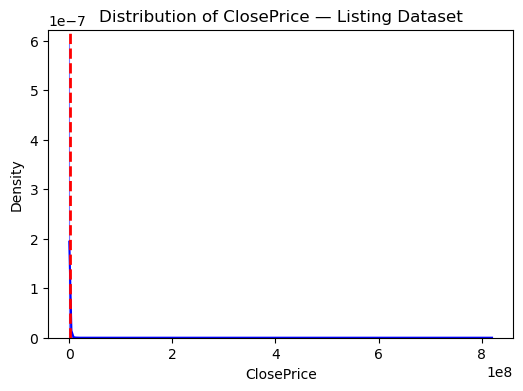

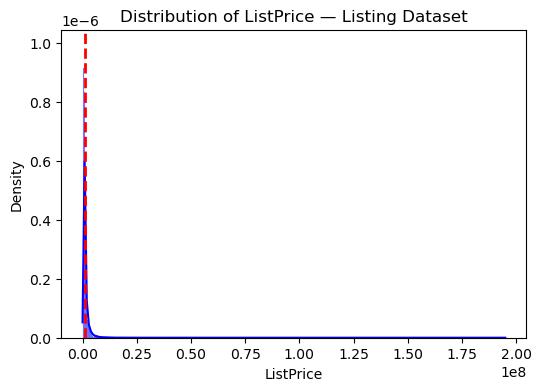

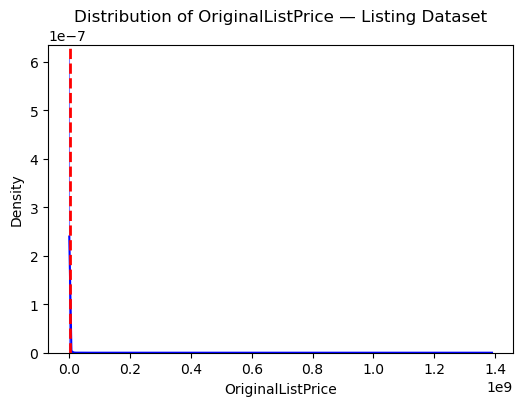

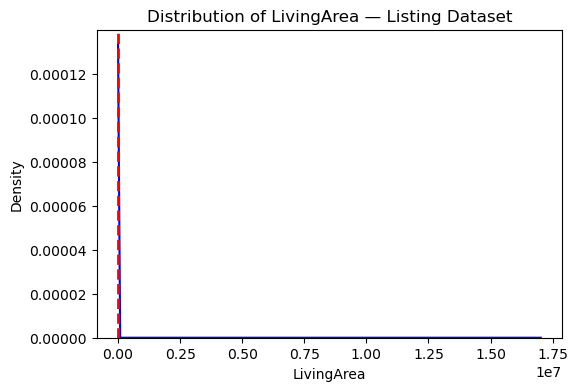

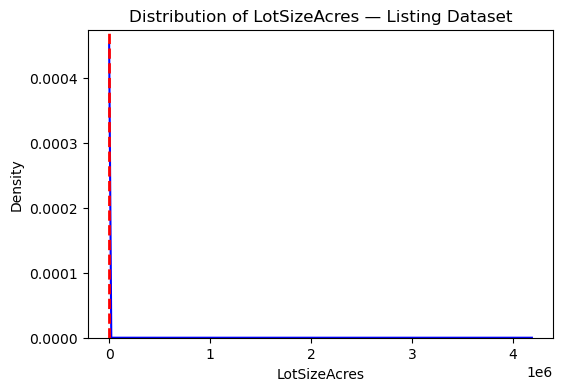

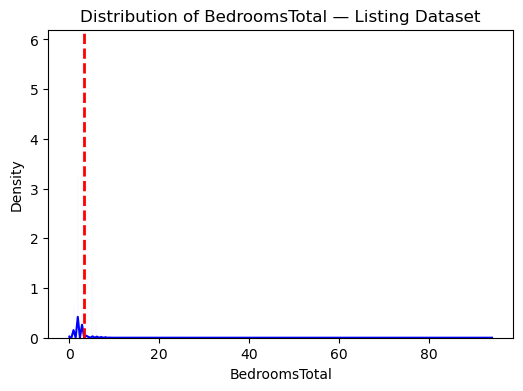

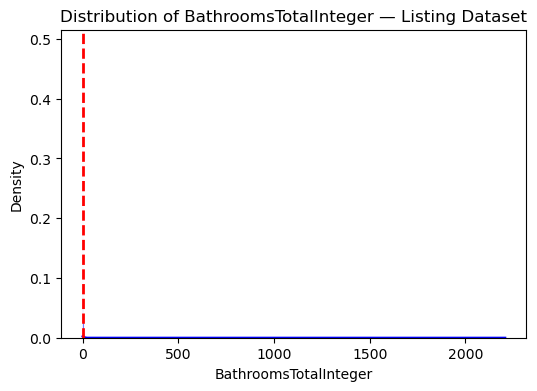

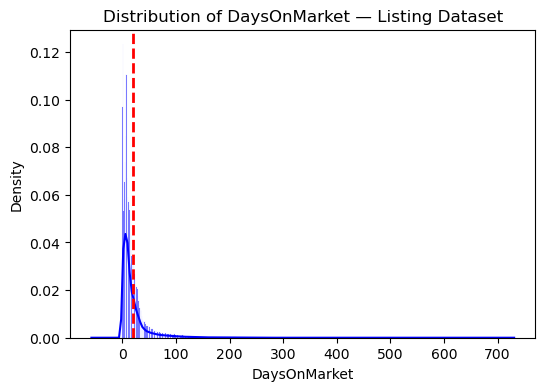

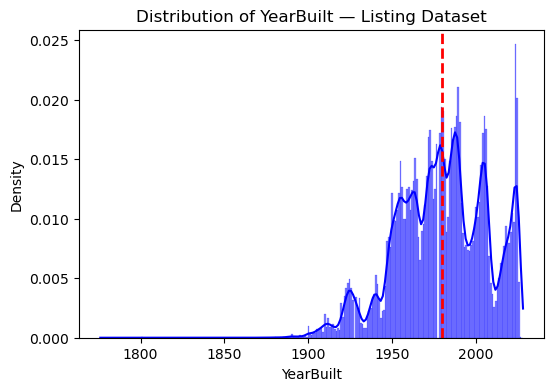

In [93]:
for col in listing_numeric_focus:
    plt.figure(figsize=(6,4))
    sns.histplot(data = listing_combined_cleaned,
             x = col, 
             edgecolor = 'blue',
             color = 'blue',
             stat='density',
             kde=True
             )
    mean_value = listing_combined_cleaned[col].mean()
    plt.axvline(x = mean_value,
                         color = 'red',
                         linestyle = '--',
                         linewidth = 2) #vertical line
    plt.title(f'Distribution of {col} — Listing Dataset')

The histograms show that most key numeric variables in the listings dataset are **highly right-skewed**, especially *ClosePrice, ListPrice, OriginalListPrice, LivingArea, and LotSizeAcres*, where a small number of extreme values stretch the upper tail. *BedroomsTotal and BathroomsTotalInteger* are centered in more typical residential ranges but still include unusual large values, while *DaysOnMarket* has a right-skewed distribution with negative observations. *YearBuilt* is comparatively stable, though a few unusual values remain. Overall, the plots confirm the presence of strong skewness, outliers, and some suspicious records in the listings data. 

### **5.2 Boxplot**

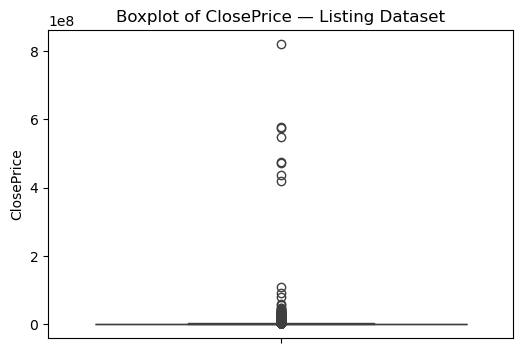

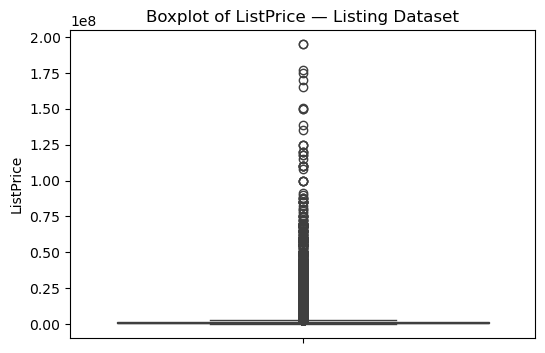

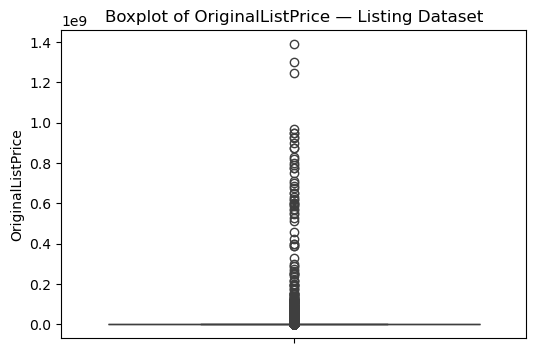

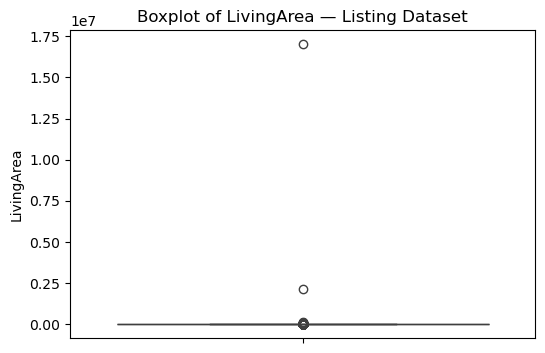

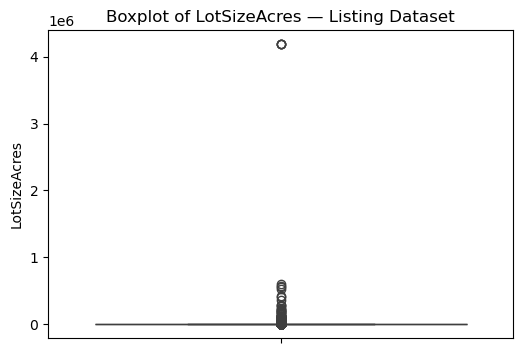

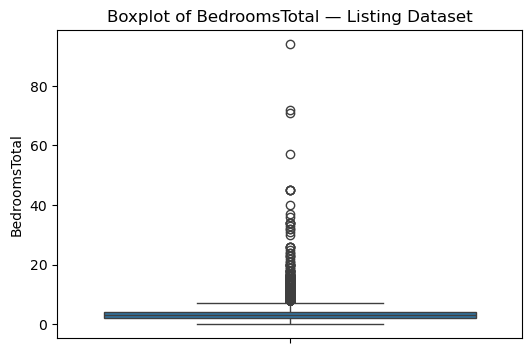

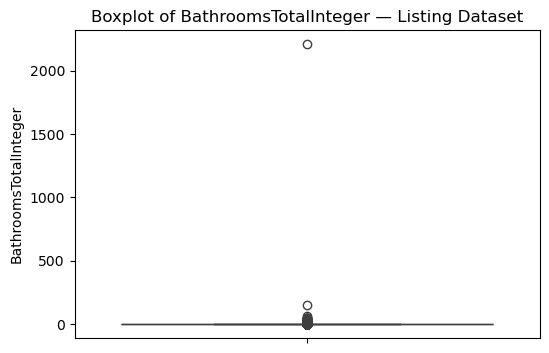

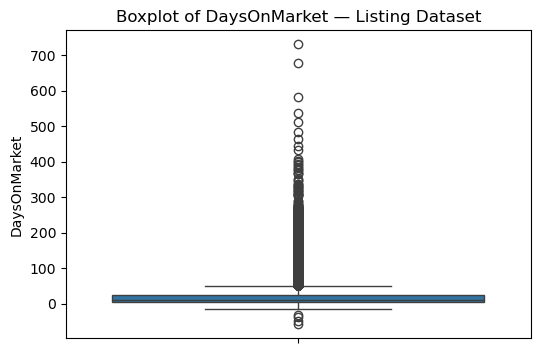

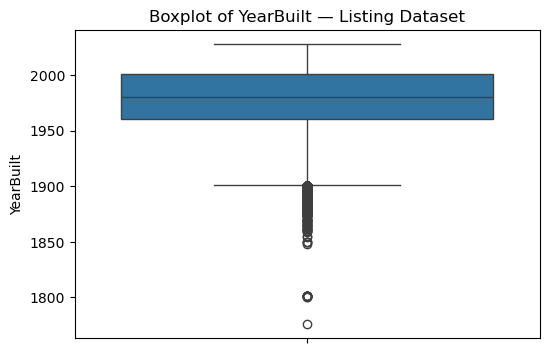

In [94]:
for col in listing_numeric_focus:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=listing_combined_cleaned[col])
    plt.title(f'Boxplot of {col} — Listing Dataset')

The boxplots confirm the conclusions from the histograms by showing that several key numeric variables are highly right-skewed and contain substantial outliers.

## 6. Outlier and strange values

#### 6.1. Outlier values applied IQR method

In [112]:
for col in listing_numeric_focus:
    #Identifying outliers using boxplot method for each key numeric column
    Q1 = listing_combined_cleaned[col].quantile(0.25)
    Q3 = listing_combined_cleaned[col].quantile(0.75)


    # Calculate the Interquartile Range (IQR)
    IQR = Q3 - Q1

    # Calculate the upper bound for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5*IQR

    print(f'Outlier bounds for {col} — Listing Dataset: [{lower_bound:.2f}, {upper_bound:.2f}]')

    outliers = listing_combined_cleaned[(listing_combined_cleaned[col] > upper_bound) | (listing_combined_cleaned[col] < lower_bound)]
    print(f'Percentage of {col} outliers — Listing Dataset:', round(len(outliers) / len(listing_combined_cleaned) * 100,2),'%\n')


Outlier bounds for ClosePrice — Listing Dataset: [-525000.00, 2475000.00]
Percentage of ClosePrice outliers — Listing Dataset: 1.94 %

Outlier bounds for ListPrice — Listing Dataset: [-612500.00, 2567500.00]
Percentage of ListPrice outliers — Listing Dataset: 8.42 %

Outlier bounds for OriginalListPrice — Listing Dataset: [-621000.00, 2595000.00]
Percentage of OriginalListPrice outliers — Listing Dataset: 8.39 %

Outlier bounds for LivingArea — Listing Dataset: [-332.50, 3879.50]
Percentage of LivingArea outliers — Listing Dataset: 4.95 %

Outlier bounds for LotSizeAcres — Listing Dataset: [-0.17, 0.60]
Percentage of LotSizeAcres outliers — Listing Dataset: 14.71 %

Outlier bounds for BedroomsTotal — Listing Dataset: [-1.00, 7.00]
Percentage of BedroomsTotal outliers — Listing Dataset: 0.32 %

Outlier bounds for BathroomsTotalInteger — Listing Dataset: [0.50, 4.50]
Percentage of BathroomsTotalInteger outliers — Listing Dataset: 6.34 %

Outlier bounds for DaysOnMarket — Listing Dataset:

#### 6.2. Strange values
-  Invalid : 
    * DaysOnMarket < 0
	* OriginalListPrice = 0
	* LivingArea = 0
	* LotSizeAcres = 0
	* BedroomsTotal = 0
	* BathroomsTotalInteger = 0
- Very large:
	* BedroomsTotal = 94
	* BathroomsTotalInteger = 2208
	* LivingArea = 17,021,320
	* LotSizeAcres = 4,187,292

- Unusual but may be possible:
	* YearBuilt = 1776, 2028


## 7. EDA

1. What are the median and average list prices?

In [114]:
median_list_price = listing_combined_cleaned['ListPrice'].median()
mean_list_price = listing_combined_cleaned['ListPrice'].mean()

print("Median ListPrice - Listing dataset:", median_list_price)
print("Average ListPrice - Listing dataset:", f"{mean_list_price:.2f}")

Median ListPrice - Listing dataset: 840000.0
Average ListPrice - Listing dataset: 1312996.78


2. What does the Days on Market distribution look like?

In [104]:
listing_combined_cleaned['DaysOnMarket'].describe()

count    540183.000000
mean         19.539904
std          26.771154
min         -58.000000
25%           5.000000
50%          11.000000
75%          23.000000
max         731.000000
Name: DaysOnMarket, dtype: float64

Histagram:

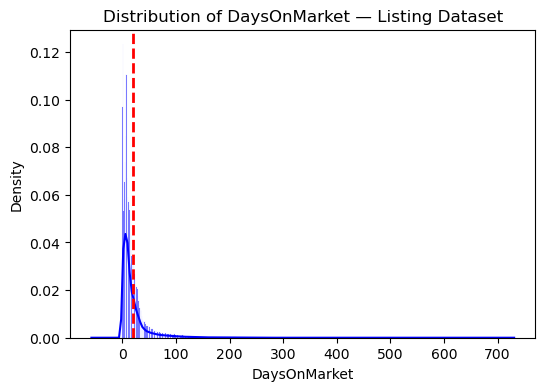

3. What percentage of listings are currently above, below, or at their original list price?


In [118]:
above_original_pct = (listing_combined_cleaned['ListPrice'] > listing_combined_cleaned['OriginalListPrice']).mean() * 100
below_original_pct = (listing_combined_cleaned['ListPrice'] < listing_combined_cleaned['OriginalListPrice']).mean() * 100
at_original_pct = (listing_combined_cleaned['ListPrice'] == listing_combined_cleaned['OriginalListPrice']).mean() * 100


# since some rows may have missing values in either ClosePrice or ListPrice, we should only consider rows where both are present for percentage calculations

total_valid = len(listing_combined_cleaned[['OriginalListPrice', 'ListPrice']].dropna())

above_pct = len(above_list_price) / total_valid * 100
below_pct = len(below_list_price) / total_valid * 100
at_pct = len(equal_list_price) / total_valid * 100

print("Above original listing price percentage - listing dataset:", f"{above_pct:.2f}%")
print("Below original listing price percentage - listing dataset:", f"{below_pct:.2f}%")

Above original listing price percentage - listing dataset: 11.87%
Below original listing price percentage - listing dataset: 10.11%


4. Are there any apparent date consistency issues?

In [106]:
listing_combined_cleaned['CloseDate'] = pd.to_datetime(listing_combined_cleaned['CloseDate'], errors='coerce')
listing_combined_cleaned['ListingContractDate'] = pd.to_datetime(listing_combined_cleaned['ListingContractDate'], errors='coerce')
listing_combined_cleaned['PurchaseContractDate'] = pd.to_datetime(listing_combined_cleaned['PurchaseContractDate'], errors='coerce')


close_before_listing = (listing_combined_cleaned['CloseDate'] < listing_combined_cleaned['ListingContractDate']).sum()
close_before_purchase = (listing_combined_cleaned['CloseDate'] < listing_combined_cleaned['PurchaseContractDate']).sum()
purchase_before_listing = (listing_combined_cleaned['PurchaseContractDate'] < listing_combined_cleaned['ListingContractDate']).sum()

print("Close date before listing date - listing combined cleaned:", close_before_listing)
print("Close date before purchase contract date - listing combined cleaned:", close_before_purchase)
print("Purchase contract date before listing date - listing combined cleaned:", purchase_before_listing)

Close date before listing date - listing combined cleaned: 72
Close date before purchase contract date - listing combined cleaned: 265
Purchase contract date before listing date - listing combined cleaned: 271


5. Which counties have the highest median list prices?

In [116]:
county_median_prices_listing = (
    listing_combined_cleaned
    .groupby('CountyOrParish')['ListPrice']
    .median()
    .sort_values(ascending=False)
)

county_median_prices_listing.head(10)

CountyOrParish
San Mateo        1648000.0
Santa Clara      1499000.0
Marin            1295000.0
Santa Cruz       1250000.0
Orange           1200000.0
San Francisco    1098000.0
Alameda           998000.0
Monterey          990000.0
Los Angeles       950000.0
San Diego         910000.0
Name: ListPrice, dtype: float64

The counties with the highest median listing prices are San Mateo. 